<a href="https://colab.research.google.com/github/Suman18-bit/Deep-Learning/blob/main/ANN_with_Data_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Importing the necessary libraries
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Fetching the California Housing dataset
housing = fetch_california_housing()

# Splitting the data into training, validation, and test sets
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

# Standardizing the data using StandardScaler
scaler = StandardScaler()

# Fitting the scaler on the training data and transforming the validation and test data
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

In [18]:
import pandas as pd

In [19]:
housing_df = pd.DataFrame(housing.data, columns=housing.feature_names)
housing_df['target'] = housing.target
housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

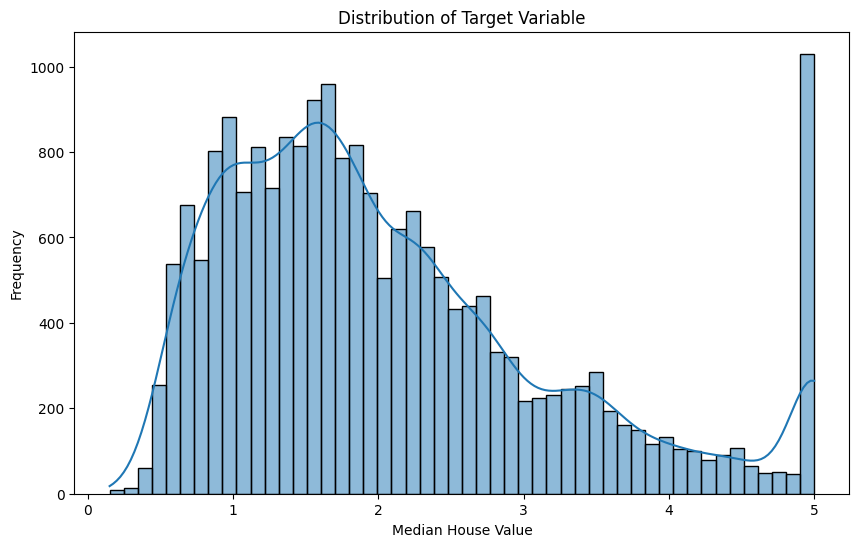

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(housing_df['target'], bins=50, kde=True)
plt.title('Distribution of Target Variable')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.savefig('target_distribution.png')
sns.pairplot(housing_df)
plt.savefig('pairplot.png')
plt.close()

In [21]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing_df.drop(columns=['target']),housing_df['target'],random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full, random_state=42)

# Standardizing the data using StandardScaler
scaler = StandardScaler()

# Fitting the scaler on the training data and transforming the validation and test data
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)


In [22]:
scaled_train_df = pd.DataFrame(X_train, columns=housing.feature_names)
scaled_train_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,-0.193979,-1.077813,-0.943385,0.014853,0.020733,-0.572916,0.929260,-1.422155
1,0.751983,-1.868895,0.405478,-0.233277,1.861465,0.205165,-0.916547,1.096670
2,-0.414691,0.029701,0.818088,1.056784,-0.087867,-0.299833,1.308729,-1.697027
3,1.718896,-1.315138,0.326644,-0.219551,-0.337922,-0.111466,-0.982134,0.941742
4,-0.962072,-1.236030,-0.056258,-0.031244,1.709059,-0.302570,-0.804112,1.326562


Text(0, 0.5, 'Frequency')

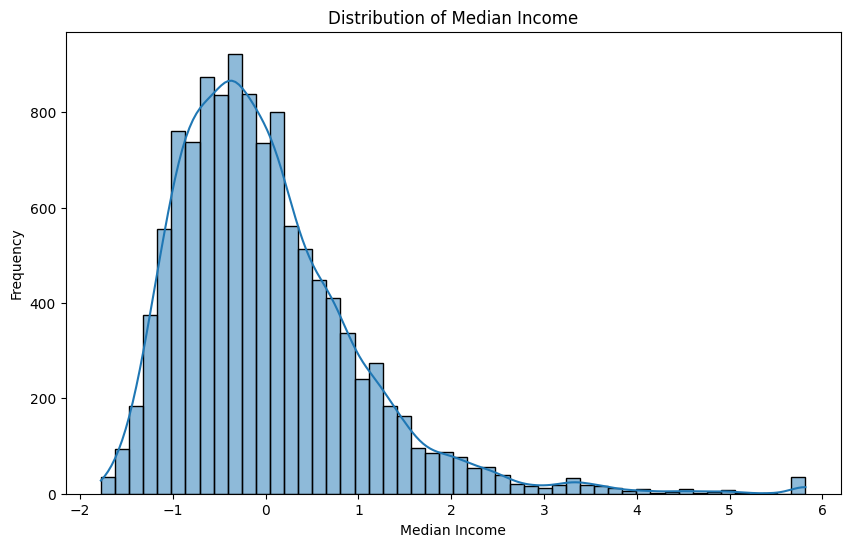

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(scaled_train_df['MedInc'], bins=50, kde=True)
plt.title('Distribution of Median Income')
plt.xlabel('Median Income')
plt.ylabel('Frequency')

In [30]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.Input(shape=(8,)), # Explicitly define Input layer
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(100, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(loss='mse', optimizer='adam')
history= model.fit(X_train, y_train, epochs=30, validation_data=(X_valid, y_valid))


Epoch 1/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.7868 - val_loss: 0.4047
Epoch 2/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3935 - val_loss: 0.6551
Epoch 3/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3639 - val_loss: 3.0597
Epoch 4/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3776 - val_loss: 3.7578
Epoch 5/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3715 - val_loss: 10.6344
Epoch 6/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3616 - val_loss: 20.1567
Epoch 7/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4937 - val_loss: 3.3968
Epoch 8/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3343 - val_loss: 0.3462
Epoch 9/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3040 - val_loss: 0.4293
Epoch 10/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3046 - val_loss: 0.9435
Epoch 11/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2995 - val_loss: 1.6305
Epoch 12/30
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/st

In [31]:
mes_test = model.evaluate(X_test, y_test)
print(mes_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2918
0.29182082414627075


In [32]:
print('Making predictions on the test set:')
y_pred = model.predict(X_test)
print(y_pred[:5])
print('\nModel Summary:')
model.summary()

Making predictions on the test set:
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[[0.35121274]
 [1.0945563 ]
 [5.0230327 ]
 [2.413104  ]
 [2.9602957 ]]

Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 100)            │           900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,305 (130.10 KB)

 Trainable params: 11,101 (43.36 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,204 (86.74 KB)

In [33]:
import gradio as gr
import numpy as np

def predict_housing_price(MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude):
    # Combine inputs into a numpy array
    input_data = np.array([[MedInc, HouseAge, AveRooms, AveBedrms, Population, AveOccup, Latitude, Longitude]])

    # Scale the input data using the pre-fitted scaler
    scaled_input_data = scaler.transform(input_data)

    # Make prediction using the trained model
    prediction = model.predict(scaled_input_data)[0][0]

    return prediction

# Create Gradio interface
iface = gr.Interface(
    fn=predict_housing_price,
    inputs=[
        gr.Number(label="Median Income (MedInc)", value=3.87),
        gr.Number(label="House Age (HouseAge)", value=29.0),
        gr.Number(label="Average Rooms (AveRooms)", value=6.24),
        gr.Number(label="Average Bedrooms (AveBedrms)", value=1.07),
        gr.Number(label="Population (Population)", value=1300.0),
        gr.Number(label="Average Occupancy (AveOccup)", value=3.09),
        gr.Number(label="Latitude (Latitude)", value=34.0),
        gr.Number(label="Longitude (Longitude)", value=-118.0)
    ],
    outputs=gr.Number(label="Predicted Median House Value"),
    title="California Housing Price Predictor",
    description="Enter the features of a house to predict its median value (in $100,000s)."
)

# Launch the interface
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://affabfbe63bf4a8900.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
